# Simulation Bell

In [1]:
%load_ext autoreload
%autoreload 2

import os
ROOT_DIR = os.getcwd()[:os.getcwd().rfind('HEOM')]+ 'HEOM'
os.chdir(ROOT_DIR)

from ttheom import *
plt.style.use('ttheom-default')

import numpy as np 
import qutip as q
import matplotlib.pyplot as plt
import pandas as pd
import time

red, blue, orange, grey = '#B74244', '#459DD9', '#ED8532', '#A9ACBC'

## local

In [1]:
from qiskit import QuantumCircuit
from ttheom import calcTimeEvo

# Qiskit quantum circuit
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)

kwargs = {
    "numQ": 2,
    "freqQ": [5, 5],  # GHz
    "rhoIni": [
        [1, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
    ],
    "gateTime": [16, 16, 50],  # ns
    "idlingTime": 1,  # ns
    "T": 30,  # mK
    "T1": 1,  # us
    "omegaC": 20,
    "exp": 1,
    "tol": 1e-6,
    "dtFB": 0.1,  # ps
    "depth": [1, 1],
    "bondDim": 5,
    "strideTime": 0.1,  # ns
    "useRFPlus": False,
    "isRK13": False,
}

kwargs["directory"] = "development/results/local/sim_Bell"
kwargs["fileName"] = "Bell_s1"
kwargs["qc"] = qc

# expected runtime
calcTimeEvo(**kwargs)

## HPC

In [8]:
from qiskit import QuantumCircuit

# Qiskit quantum circuit
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)

kwargs = {
    "numQ": 2,
    "freqQ": [5, 5],  # GHz
    "rhoIni": [
        [1, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
    ],
    "gateTime": [16, 16, 50],  # ns
    "idlingTime": 1,  # ns
    "T": 30,  # mK
    "T1": 1,  # us
    "omegaC": 20,
    "exp": 1,
    "tol": 1e-6,
    "dtFB": 0.1,  # ps
    "depth": [1, 1],
    "bondDim": 5,
    "strideTime": 0.1,  # ns
    "useRFPlus": False,
    "isRK13": False,
}

kwargs["directory"] = "development/results/hpc/sim_Bell"
kwargs["fileName"] = "Bell_s1"
kwargs["qc"] = qc

In [10]:
submissionParams = {
    "hostname":      "cluster.example.org",
    "username":      "myusername",
    "password":      "mypassword",
    "schedulerName": "slurm",
    "numNodes":      1,
    "cpusPerTask":   1,
    "maxTime":       "336:00:00",
    "venvPath":      '$HOME/python_HEOM/.venv',
    "emailAddress":  "user@example.org",
    "others":        "",
}

calcTimeEvoHPC(submissionParams, **kwargs)

Your OTP:  ········


Submitted batch job 21820369

Save the job ID! It is used for getting results.


In [ ]:
# download result

directory = "development/results/hpc/sim_Bell"
fileName = "Bell_s1"
csvFilePath = os.path.join(os.getcwd(), directory, fileName + '.csv')

jobID = "myjobid"

downloadParams = {
    "hostname":      "cluster.example.org",
    "username":      "myusername",
    "password":      "mypassword",
    "schedulerName": "slurm",
}
import getpass
downloadParams['otp'] = getpass.getpass('Your OTP: ')

downloadResult(downloadParams, jobID, csvFilePath)

## reload

In [ ]:
directory = "development/results/paper/sim_Bell"
fileNames = ['Bell_s1', 'Bell_s2', 'Bell_s8']

for i, fileName in enumerate(fileNames):
    
    # load kwargs from QPY file 
    kwargs = getKwargs(directory, fileName)
    print(kwargs)
    print('------------')
    print(kwargs['qc'].metadata)
    print('------------')

    fig, ax = plt.subplots()
    kwargs['qc'].draw('mpl', ax=ax)
    
    # load result from CSV file
    # t_list, rdo_list = getResult(directory, fileName)

## eval

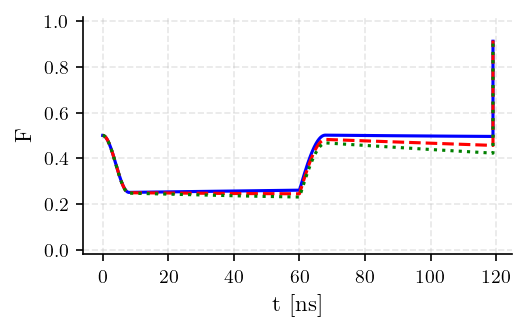

In [16]:
directory = "development/results/paper/sim_Bell"
fileNames = ['Bell_s8', 'Bell_s2', 'Bell_s1']

fig, ax = plt.subplots()

colors = ['b', 'r', 'g']
labels = [r'$s=1/8$', r'$s=1/2$', r'$s=1$']
ls = ['-','--', ':']

for i, fileName in enumerate(fileNames):
    
    kwargs = getKwargs(directory, fileName)
    t_list, rdo_list = getResult(directory, fileName)

    omegaQ = 2*np.pi*np.array(kwargs['freqQ'])
    omegaQmax = max(omegaQ)
    t = t_list / omegaQmax

    U = Operator(kwargs["qc"]).data
    target = U @ kwargs["rhoIni"] @ U.conj().T
    fids = [getFidelity(rho, target) for rho in rdo_list]

    ax.plot(t, fids, linewidth=1.5, color=colors[i], label=labels[i], ls=ls[i])
    ax.set_xlabel("t [ns]")
    ax.set_ylabel("F")
    ax.set_ylim(-0.02, 1.02)
    ax.grid(True, alpha=0.3)

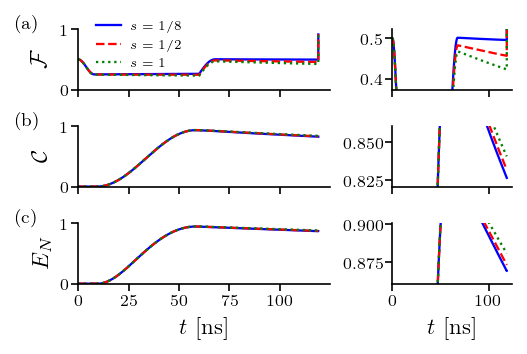

In [72]:
directory = "development/results/paper/sim_Bell"
fileNames = ['Bell_s8', 'Bell_s2', 'Bell_s1']

colors = ["b", "r", "g"]
labels = [r"$s=1/8$", r"$s=1/2$", r"$s=1$"]
ls = ["-", "--", ":"]

fig, axes = plt.subplots(
    3, 2,
    figsize=(3.4, 3.0*3/4),
    sharex="col",
    gridspec_kw={"width_ratios": [2.1, 1.0]},
)

ylabels = [
    r"$\mathcal{F}$",
    r"$\mathcal{C}$",
    r"$E_N$",
]

for i, fileName in enumerate(fileNames):
    kwargs = getKwargs(directory, fileName)
    t_list, rdo_list = getResult(directory, fileName)

    omegaQ = 2 * np.pi * np.array(kwargs["freqQ"])
    omegaQmax = max(omegaQ)
    t = t_list / omegaQmax

    U = Operator(kwargs["qc"]).data
    target = U @ kwargs["rhoIni"] @ U.conj().T

    data = [
        [getFidelity(dm, target) for dm in rdo_list],
        [getConcurrence(dm) for dm in rdo_list],
        [getLogarithmicNegativity(dm, [0]) for dm in rdo_list],
    ]

    for row, y in enumerate(data):
        axes[row, 0].plot(t, y, color=colors[i], label=labels[i], ls=ls[i], lw=1.1)
        axes[row, 1].plot(t, y, color=colors[i], ls=ls[i], lw=1.1)

for row in range(3):
    axes[row, 0].set_ylabel(ylabels[row])
    axes[row, 0].set_xlim(0)
    axes[row, 0].set_ylim(0,1)

    axes[row, 1].set_xlim(0)

axes[0, 1].set_ylim(data[0][-2]-0.05, data[0][-2]+0.1)
axes[1, 1].set_ylim(data[1][-2]-0.02, data[1][-2]+0.02)
axes[2, 1].set_ylim(data[2][-2]-0.02, data[2][-2]+0.02)

for ax in axes[:-1, :].ravel():
    ax.tick_params(labelbottom=False)

axes[-1, 0].set_xlabel(r"$t$ [ns]")
axes[-1, 1].set_xlabel(r"$t$ [ns]")

axes[0, 0].legend(fontsize=6, frameon=False, ncols=1, bbox_to_anchor=(30, 0.75), loc='center', bbox_transform=axes[0, 0].transData)

# panel labels
panel_labels = ["(a)", "(b)", "(c)"]
for i, label in enumerate(panel_labels):
    axes[i,0].text(
        -0.25,
        1.25,
        label,
        transform=axes[i,0].transAxes,
        ha="left",
        va="top",
        fontsize=9,
        fontweight="bold",
    )

for ax in axes.flatten():
    ax.set_xlim(0)
    ax.tick_params(axis="both", labelsize=8, pad=1)

fig.savefig(os.path.join(directory, "Bell_comparison.pdf"), bbox_inches="tight")
fig.savefig(os.path.join(directory, "Bell_comparison.svg"), bbox_inches="tight")